# Notebook 13: SU(N) Generalization

**Learning objectives:**
- Understand how SU(2) quaternions generalize to SU(N) complex matrices
- Generate random SU(3) matrices and verify group properties
- Compare SU(2) and SU(3) eigenvalues, traces, and determinants
- Understand what changes for physics at $N_c = 3$ (real QCD)

**Prerequisites:** Notebook 01 (SU(2) group theory)

**Source code:** `su2/meson_correlator/sun.py`

In [1]:
from notebook_utils import setup_paths
setup_paths()

import numpy as np
import matplotlib.pyplot as plt
import su2   # SU(2) with quaternion representation
import sun   # SU(N) with complex matrix representation

/home/zeke/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. SU(2): Quaternions vs Complex Matrices

In Notebooks 01-11, SU(2) matrices are stored as **4-component real vectors**
(quaternions): $U = [a_0, a_1, a_2, a_3]$ with $\sum a_i^2 = 1$.

The `sun.py` module uses a more general representation: **$N \times N$
complex matrices** with $U^\dagger U = I$ and $\det U = 1$. These
unitary-with-unit-determinant matrices form the group $SU(N)$, which has
$N^2 - 1$ real parameters (High Energy Physics Essentials §6.1.4–6.1.5, Exercise 6.16).

For SU(2), both representations are equivalent:
$$U = a_0 I + i(a_1 \sigma_1 + a_2 \sigma_2 + a_3 \sigma_3) = \begin{pmatrix} a_0 + ia_3 & a_2 + ia_1 \\ -a_2 + ia_1 & a_0 - ia_3 \end{pmatrix}$$

Here the $\sigma_a$ are the Pauli matrices, and the three generators
$T^a = \sigma^a/2$ define the fundamental representation of SU(2)
(High Energy Physics Essentials Ch. 6).

In [2]:
# Compare quaternion and matrix representations
U_quat = su2.hstart()  # quaternion: [a0, a1, a2, a3]
print("SU(2) quaternion representation:")
print(f"  U = {U_quat}")
print(f"  det = {su2.det(U_quat):.10f}")
print(f"  Tr  = {su2.tr(U_quat):.6f}")

# Reconstruct as 2x2 complex matrix
sigma = [np.eye(2, dtype=complex),
         np.array([[0, 1], [1, 0]], dtype=complex),        # sigma_1
         np.array([[0, -1j], [1j, 0]]),                    # sigma_2
         np.array([[1, 0], [0, -1]], dtype=complex)]       # sigma_3

U_matrix = U_quat[0] * sigma[0]
for i in range(1, 4):
    U_matrix += 1j * U_quat[i] * sigma[i]

print("\nAs 2x2 complex matrix:")
print(U_matrix)
print(f"  det = {np.linalg.det(U_matrix):.10f}")
print(f"  Tr  = {np.trace(U_matrix):.6f}")
print(f"  U^dag U = I: {np.allclose(U_matrix.conj().T @ U_matrix, np.eye(2))}")

SU(2) quaternion representation:
  U = [-0.64150954  0.62017075  0.22252964  0.39285406]
  det = 1.0000000000
  Tr  = -1.283019

As 2x2 complex matrix:
[[-0.64150954+0.39285406j  0.22252964+0.62017075j]
 [-0.22252964+0.62017075j -0.64150954-0.39285406j]]
  det = 1.0000000000+0.0000000000j
  Tr  = -1.283019+0.000000j
  U^dag U = I: True


## 2. SU(3): Real QCD

Real QCD uses $N_c = 3$ colors. SU(3) matrices are $3 \times 3$ unitary
matrices with determinant 1. They have 8 real parameters (the Gell-Mann
matrices $\lambda_1, \ldots, \lambda_8$ are the generators of the
fundamental representation; High Energy Physics Essentials Exercise 6.26 lists the
standard basis explicitly, with structure constants $f^{abc}$ defined
through $[T^a, T^b] = if^{abc}T^c (High Energy Physics Essentials Ch. 6).

Group elements are recovered by exponentiation: a finite SU(N)
transformation is $U = \exp(i\theta^a T^a)$ (High Energy Physics Essentials Ch. 6),
which is exactly how `sun.py` builds random group elements from random
algebra-valued matrices. See Creutz Ch. 11 for the invariant (Haar)
measure used to integrate over the group.

| Property | SU(2) | SU(3) |
|----------|-------|-------|
| Matrix size | $2 \times 2$ | $3 \times 3$ |
| Parameters | 3 | 8 |
| Generators | Pauli $\sigma_i$ | Gell-Mann $\lambda_a$ |
| $\det U$ | 1 | 1 |
| Storage per link | 4 reals | 18 reals ($9$ complex) |
| Dirac matrix size | $8V \times 8V$ | $12V \times 12V$ |

In [3]:
# Generate SU(3) matrices and verify properties
print("SU(3) matrix generation:")
U3 = sun.random_SU_N(3)
print(f"Shape: {U3.shape}")
print(f"U =\n{U3}\n")
print(f"det(U) = {np.linalg.det(U3):.10f}  (should be 1)")
print(f"Tr(U)  = {np.trace(U3):.6f}")
print(f"U^dag U = I: {np.allclose(U3.conj().T @ U3, np.eye(3))}")

SU(3) matrix generation:
Shape: (3, 3)
U =
[[-0.13693806-0.43264171j  0.1040225 +0.51801895j  0.55024347+0.46058325j]
 [-0.02430838+0.72864406j -0.32906433-0.13649571j  0.48657716+0.32375173j]
 [ 0.0011033 -0.51240105j -0.42241435-0.64458311j  0.36598774-0.09785523j]]

det(U) = 1.0000000000+0.0000000000j  (should be 1)
Tr(U)  = -0.100015-0.666993j
U^dag U = I: True


In [4]:
# Verify group axioms for SU(3)
U1 = sun.random_SU_N(3)
U2 = sun.random_SU_N(3)
U3g = sun.random_SU_N(3)

# Closure
prod = U1 @ U2
print("=== SU(3) Group Axioms ===")
print(f"Closure: det(U1*U2) = {np.linalg.det(prod):.10f}")
print(f"  U^dag U = I: {np.allclose(prod.conj().T @ prod, np.eye(3))}")

# Associativity
lhs = (U1 @ U2) @ U3g
rhs = U1 @ (U2 @ U3g)
print(f"Associativity: max diff = {np.max(np.abs(lhs - rhs)):.2e}")

# Identity
I3 = sun.identity_SU_N(3)
print(f"Identity: max|U*I - U| = {np.max(np.abs(U1 @ I3 - U1)):.2e}")

# Inverse
inv_check = U1 @ U1.conj().T
print(f"Inverse: max|U*U^dag - I| = {np.max(np.abs(inv_check - np.eye(3))):.2e}")

=== SU(3) Group Axioms ===
Closure: det(U1*U2) = 1.0000000000-0.0000000000j
  U^dag U = I: True
Associativity: max diff = 2.48e-16
Identity: max|U*I - U| = 0.00e+00
Inverse: max|U*U^dag - I| = 4.44e-16


## 3. Eigenvalue Comparison

SU(N) eigenvalues lie on the unit circle: $\lambda_k = e^{i\theta_k}$
with $\prod_k \lambda_k = 1$ ($\det U = 1$).

- SU(2): 2 eigenvalues, always conjugate pairs $e^{\pm i\theta}$
- SU(3): 3 eigenvalues, $e^{i\theta_1} e^{i\theta_2} e^{i\theta_3} = 1$

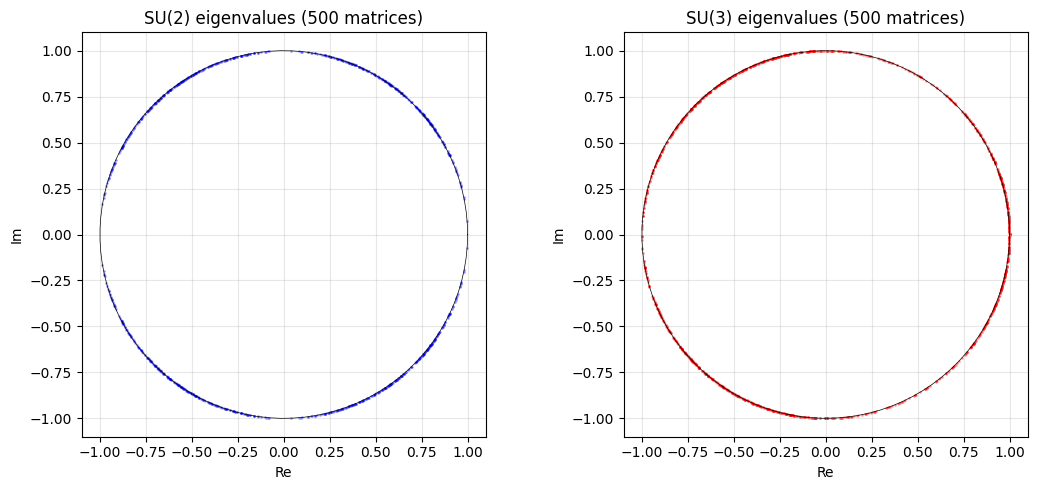

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# SU(2) eigenvalues
N_samples = 500
for _ in range(N_samples):
    U_q = su2.hstart()
    U_m = U_q[0] * sigma[0]  # sigma already complex from cell-3
    for i in range(1, 4):
        U_m += 1j * U_q[i] * sigma[i]
    eigs = np.linalg.eigvals(U_m)
    ax1.scatter(eigs.real, eigs.imag, s=1, c='blue', alpha=0.3)

circle = np.exp(1j * np.linspace(0, 2*np.pi, 100))
ax1.plot(circle.real, circle.imag, 'k-', linewidth=0.5)
ax1.set_xlabel('Re'); ax1.set_ylabel('Im')
ax1.set_title(f'SU(2) eigenvalues ({N_samples} matrices)')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# SU(3) eigenvalues
for _ in range(N_samples):
    U3 = sun.random_SU_N(3)
    eigs = np.linalg.eigvals(U3)
    ax2.scatter(eigs.real, eigs.imag, s=1, c='red', alpha=0.3)

ax2.plot(circle.real, circle.imag, 'k-', linewidth=0.5)
ax2.set_xlabel('Re'); ax2.set_ylabel('Im')
ax2.set_title(f'SU(3) eigenvalues ({N_samples} matrices)')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**About the circle.** The black curve in each panel is the unit circle
$|\lambda| = 1$, drawn as a visual reference. Every eigenvalue of an
SU(N) matrix is a phase $\lambda = e^{i\theta}$, so it must land *exactly*
on this circle — that is what unitarity ($U^\dagger U = \mathbb{1}$) means
in spectral form. We overlay the circle so that you can see, by eye, that
both the SU(2) and SU(3) scatter clouds sit on it. If a single point ever
fell off the circle, the corresponding matrix would not be unitary.

Notice also the structural difference between the two panels:
- **SU(2)** eigenvalues come in *complex-conjugate pairs* $e^{\pm i\theta}$,
  so each random matrix contributes two points symmetric about the real
  axis. The cloud is a single ring, denser near $\theta = \pm \pi/2$ for
  the Haar measure.
- **SU(3)** eigenvalues are three independent phases constrained only by
  $\theta_1 + \theta_2 + \theta_3 \equiv 0 \pmod{2\pi}$ (det $U = 1$).
  The ring is "filled in" more uniformly, and individual matrices are
  not symmetric about the real axis.

This is your first visual encounter with the difference between the
$Z_2$ center of SU(2) and the $Z_3$ center of SU(3), which becomes
important for confinement in NB12. (The discrete cyclic groups $Z_n$
are introduced in High Energy Physics Essentials §6.1 — Exercise 6.4 — as the simplest
example of a finite group; see Creutz Ch. 12 for their role as the
center of $SU(N)$ and as an order parameter for the deconfinement
transition.)

## 4. Trace Distributions

The trace distribution depends on $N_c$:
- SU(2): $\mathrm{Tr}(U) = 2\cos\theta \in [-2, 2]$, semicircle distribution
- SU(3): $\mathrm{Tr}(U) = e^{i\theta_1} + e^{i\theta_2} + e^{i\theta_3}$ is complex,
  with $|\mathrm{Tr}| \in [0, 3]$

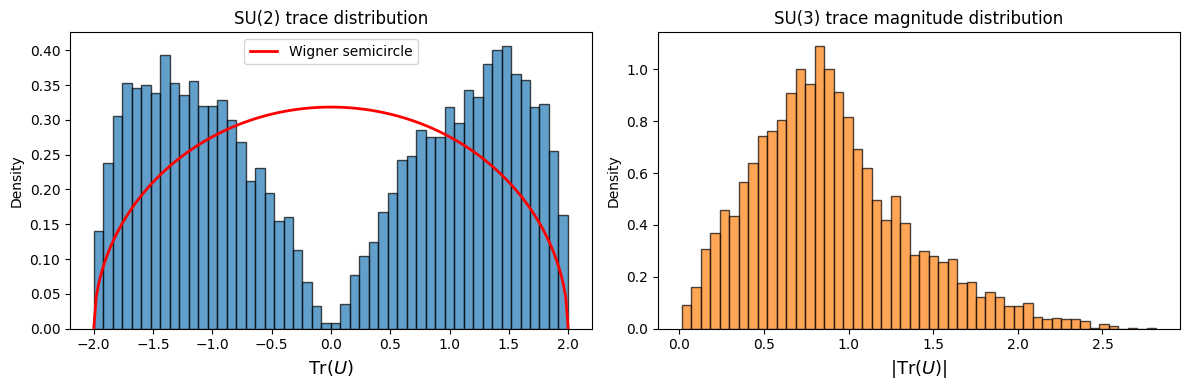

SU(2) <Tr>:  0.0134 (expected: 0)
SU(3) <|Tr|>: 0.8935


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

N_samples = 5000

# SU(2) traces (real)
traces_2 = np.array([su2.tr(su2.hstart()) for _ in range(N_samples)])
ax1.hist(traces_2, bins=50, density=True, alpha=0.7, edgecolor='k')
x = np.linspace(-2, 2, 200)
ax1.plot(x, 2/(np.pi*4) * np.sqrt(np.maximum(4 - x**2, 0)), 'r-',
         linewidth=2, label='Wigner semicircle')
ax1.set_xlabel(r'$\mathrm{Tr}(U)$', fontsize=13)
ax1.set_ylabel('Density')
ax1.set_title('SU(2) trace distribution')
ax1.legend()

# SU(3) |Tr| distribution
traces_3 = np.array([np.abs(np.trace(sun.random_SU_N(3)))
                     for _ in range(N_samples)])
ax2.hist(traces_3, bins=50, density=True, alpha=0.7, edgecolor='k',
         color='C1')
ax2.set_xlabel(r'$|\mathrm{Tr}(U)|$', fontsize=13)
ax2.set_ylabel('Density')
ax2.set_title('SU(3) trace magnitude distribution')

plt.tight_layout()
plt.show()

print(f"SU(2) <Tr>:  {np.mean(traces_2):.4f} (expected: 0)")
print(f"SU(3) <|Tr|>: {np.mean(traces_3):.4f}")

## 5. Matrix Size Scaling

The computational cost of lattice QCD scales steeply with $N_c$:

- Gauge field storage: $V \times 4 \times N_c^2$ complex numbers
- Dirac matrix: $(2N_c \cdot 4 \cdot V)^2$ entries (sparse)
- Inversion cost: $\propto N_c^3$ per site (matrix-vector products)

In [7]:
header = ["N_c", "Link storage", "Dirac size (4^4)", "Dirac size (8^3x20)"]
rows = []
for Nc in [2, 3, 4, 5]:
    link_reals = 2 * Nc**2
    V_small = 4**4
    V_large = 8**3 * 20
    D_small = 2 * Nc * 4 * V_small
    D_large = 2 * Nc * 4 * V_large
    rows.append([f"{Nc}",
                 f"{link_reals} reals",
                 f"{D_small} x {D_small}",
                 f"{D_large} x {D_large}"])

# Right-align every column to its widest cell (header or data)
widths = [max(len(h), *(len(r[i]) for r in rows)) for i, h in enumerate(header)]
sep = "  |  "
table_width = sum(widths) + len(sep) * (len(widths) - 1)

print(sep.join(f"{h:>{w}s}" for h, w in zip(header, widths)))
print("-" * table_width)
for r in rows:
    print(sep.join(f"{c:>{w}s}" for c, w in zip(r, widths)))

print(f"\nMemory for gauge field on 8^3 x 20 lattice:")
V_prod = 8**3 * 20
for Nc in [2, 3]:
    if Nc == 2:
        mem = V_prod * 4 * 4 * 8         # SU(2) quaternion: 4 reals per link, 8 bytes each
    else:
        mem = V_prod * 4 * Nc * Nc * 16  # SU(N) complex matrix: 16 bytes per entry
    print(f"  SU({Nc}): {mem / 1024**2:.2f} MB")

N_c  |  Link storage  |  Dirac size (4^4)  |  Dirac size (8^3x20)
-----------------------------------------------------------------
  2  |       8 reals  |       4096 x 4096  |      163840 x 163840
  3  |      18 reals  |       6144 x 6144  |      245760 x 245760
  4  |      32 reals  |       8192 x 8192  |      327680 x 327680
  5  |      50 reals  |     10240 x 10240  |      409600 x 409600

Memory for gauge field on 8^3 x 20 lattice:
  SU(2): 1.25 MB
  SU(3): 5.62 MB


## 6. What Changes for Physics at $N_c = 3$?

Moving from SU(2) to SU(3) introduces several key differences:

1. **Color confinement**: SU(3) has a more complex center symmetry ($Z_3$ vs $Z_2$),
   leading to a richer deconfinement phase transition (Creutz Ch. 12).

2. **More gluons**: SU(2) has 3 gluons ($N_c^2 - 1$); SU(3) has 8. More gluon
   self-interactions make the theory more strongly coupled. The $N^2 - 1$
   counting is the dimension of the adjoint representation (High Energy Physics Essentials Ch. 6, $C_2(G) = N$).

3. **Quark representations**: Quarks come in the **fundamental** ($N_c$-dimensional)
   representation, with quadratic Casimir $C_2(N) = (N^2 - 1)/(2N)$
   (High Energy Physics Essentials Ch. 6). The color structure of hadrons changes:
   - SU(2): mesons ($q\bar{q}$) and baryons ($qq$) — baryons are bosons!
   - SU(3): mesons ($q\bar{q}$) and baryons ($qqq$) — baryons are fermions (proton, neutron)

4. **Computational cost**: The $N_c^2$ scaling of storage and $N_c^3$ of linear algebra
   makes SU(3) roughly $3-5\times$ more expensive than SU(2) per site.

## Exercises

1. **SU(3) closure verification**: Generate 1000 pairs of random SU(3) matrices.
   Verify that the product is always SU(3) by checking
   $|\det(U_1 U_2) - 1| < 10^{-10}$ and $\|U^\dagger U - I\| < 10^{-10}$.

2. **SU(2) vs SU(3) plaquettes**: For the cold configuration (all identity links),
   the average plaquette is $1/N_c \cdot \mathrm{Tr}(I_{N_c}) = 1$ for any $N_c$.
   Verify this analytically and explain why.

3. **Memory scaling**: For lattice sizes $L = 8, 16, 32, 64$ with $L_t = 2L_s$,
   compute the gauge field memory requirements for SU(2) and SU(3).
   At what $L$ does SU(3) exceed 10 GB? This is why large-scale lattice QCD
   requires supercomputers.